# 06 — The Mid-Season Exodus: transfer data

Assemble and validate the departures table (Jul-Aug outbound moves from Brasíleirão clubs, 2012–2024 excl. 2020) from the open dcaribou Transfermarkt dump, and show the transfer landscape. All logic lives in `brasileirao.transfers`; this notebook is narrative + figures only.

In [1]:
from brasileirao import transfers, ingest, plotting
import matplotlib.pyplot as plt
import pandas as pd

plotting.style()
matches = ingest.load()
dep = transfers.build()
print(f"departures: {len(dep)} rows, "
      f"{dep.groupby(['club','season']).ngroups} treated club-seasons")
print(f"market value present: {dep['market_value_eur'].notna().mean():.0%}")
dep.head(10)

departures: 64 rows, 53 treated club-seasons
market value present: 92%


,club,season,transfer_date,is_placeholder_date,player,market_value_eur,to_club
0,Gremio,2012,2012-07-01,True,Mário Fernandes,9000000.0,CSKA Moscow
1,Internacional,2012,2012-07-20,False,Lucas Lima,200000.0,Botafogo
2,Athletico-PR,2013,2013-08-01,True,Thuram,150000.0,Aris Limassol
3,Sao Paulo,2013,2013-07-01,True,Dener,NaN,Ituano
4,Athletico-PR,2014,2014-08-01,True,Thuram,150000.0,Monte Azul
5,Coritiba,2014,2014-07-23,False,Felipe Abner,150000.0,RM Castilla
6,Coritiba,2015,2015-07-04,False,Welinton,1750000.0,Flamengo
7,Flamengo,2015,2015-07-09,False,Welinton,1750000.0,Umm Salal SC
8,Flamengo,2015,2015-08-10,False,Bressan,2500000.0,Grêmio
9,Fluminense,2015,2015-08-07,False,Bryan Olivera,100000.0,LA Galaxy II


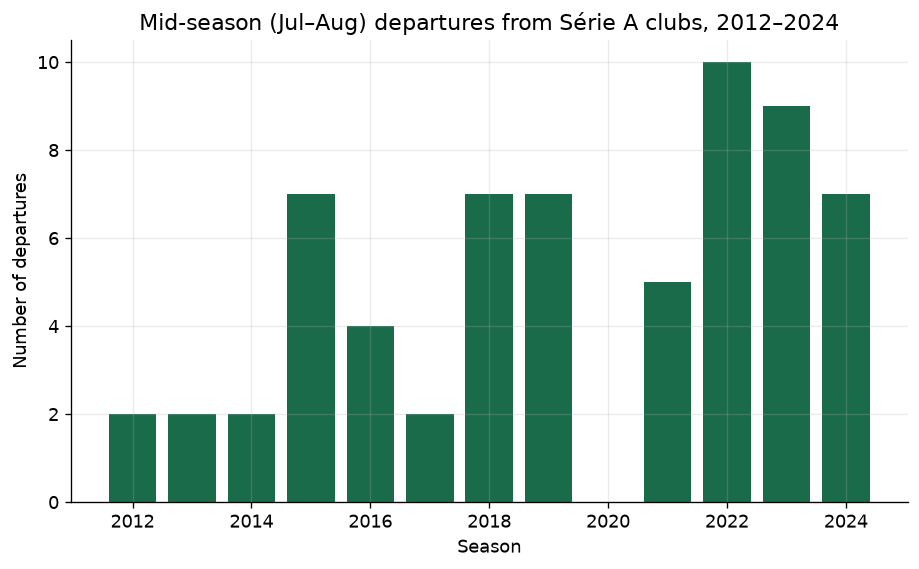

In [2]:
by_season = dep.groupby('season').size()
fig, ax = plt.subplots()
ax.bar(by_season.index, by_season.values, color=plotting.COLORS['main'])
ax.set(title="Mid-season (Jul–Aug) departures from Série A clubs, 2012–2024",
       xlabel="Season", ylabel="Number of departures")
plotting.save(fig, 'exodus_departures_by_season')

,season,club,player,market_value_eur,to_club
34,2021,Bragantino,Claudinho,11000000.0,Zenit S-Pb
35,2021,Fluminense,Marcos Paulo,9000000.0,Atlético
0,2012,Gremio,Mário Fernandes,9000000.0,CSKA Moscow
46,2022,Santos,Kaiky,8000000.0,UD Almería
12,2015,Sao Paulo,Souza,7500000.0,Fenerbahce
13,2016,Corinthians,Felipe,6000000.0,FC Porto
19,2018,Athletico-PR,Sidcley,4000000.0,Dynamo Kyiv
56,2023,Santos,Deivid Washington,4000000.0,Chelsea


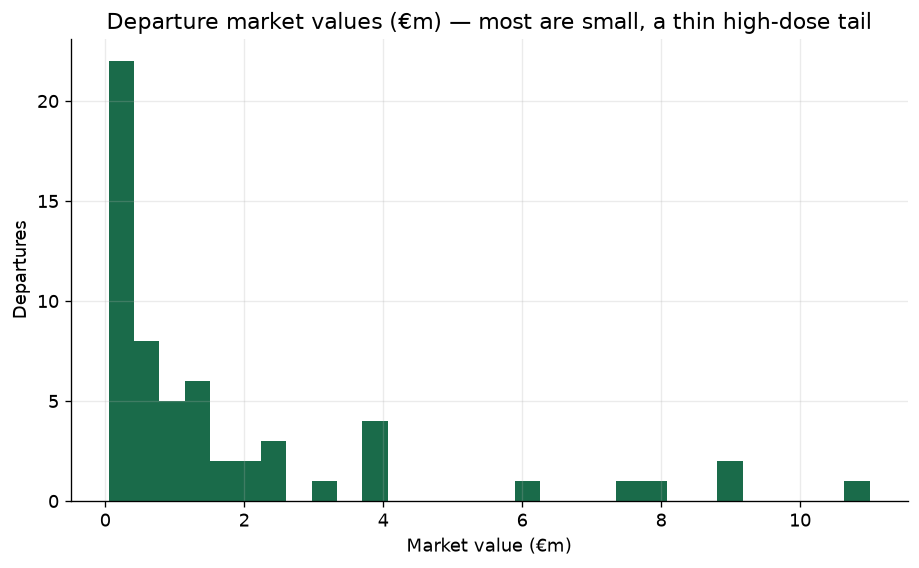

In [3]:
mv = dep['market_value_eur'].dropna() / 1e6
fig, ax = plt.subplots()
ax.hist(mv, bins=30, color=plotting.COLORS['main'])
ax.set(title="Departure market values (€m) — most are small, a thin high-dose tail",
       xlabel="Market value (€m)", ylabel="Departures")
plotting.save(fig, 'exodus_value_distribution')
dep.sort_values('market_value_eur', ascending=False).head(8)[
    ['season', 'club', 'player', 'market_value_eur', 'to_club']]

In [4]:
dest = dep['to_club'].fillna('unknown').value_counts().head(12)
print(dest)

to_club
Portimonense     5
RM Castilla      2
Flamengo         2
Fenerbahce       2
Estoril Praia    2
Sampaio-RJ       2
Gil Vicente      2
Zenit S-Pb       2
RWDM             2
UD Almería       2
Santa Clara      2
CSKA Moscow      1
Name: count, dtype: int64
